# Listings data preparation 
In this notebook we prepare Airbnb listings dataset for predictive modeling. We aim to identify the variables that may explain listing prices in Rome and clean the dataset. 

The notebook includes:

1. Data loading and exploration
2. Feature selection
3. Data cleaning
4. Missing value treatment
5. Feature engineering
6. Export of the processed dataset

The final output will be used in later notebooks for predictive modeling of nightly listing prices.

#### Environment Setup
We import all libraries required throughout the notebook for data cleaning, preprocessing and feature engineering.

In [94]:
#setup
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pandas as pd
import numpy as np
from geopy.distance import geodesic as gp
import seaborn as sns


PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: /Users/antoniacordova/Data for business/airbnb-rome-analysis


## 1. Load Airbnb Listings Dataset

The Airbnb listings dataset contains information about properties, hosts, reviews, amenities, availability and geographic location.

In [95]:
listings = pd.read_csv(
    PROJECT_ROOT / "data" / "listings.csv.gz",
    compression="gzip",
    low_memory=False
)

## 2. Exploration
Before selecting variables, we perform an initial inspection of the dataset to understand its size, data types and available attributes.

In [96]:
listings.shape

(37652, 79)

In [97]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            37652 non-null  int64  
 1   listing_url                                   37652 non-null  str    
 2   scrape_id                                     37652 non-null  int64  
 3   last_scraped                                  37652 non-null  str    
 4   source                                        37652 non-null  str    
 5   name                                          37652 non-null  str    
 6   description                                   36703 non-null  str    
 7   neighborhood_overview                         17721 non-null  str    
 8   picture_url                                   37652 non-null  str    
 9   host_id                                       37652 non-null  int64  
 1

We can see in the output that the dataset contains property information, host characteristics, review metrics and geographic variables.

In [98]:
listings.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

## 3. Target variable preparation
In the dataset the `price` variable is stored as text and contains currency symbols.
To use it in our models, it must be converted into a numeric format. 

In [99]:
listings["price"].head()

0     $57.00
1    $110.00
2    $124.00
3    $162.00
4    $150.00
Name: price, dtype: str

In [100]:
listings["price"].isna().sum()

np.int64(4088)

In [101]:
listings["price"] = (
    listings["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [102]:
# to verify
listings["price"].head()

0     57.0
1    110.0
2    124.0
3    162.0
4    150.0
Name: price, dtype: float64

Feature selection was guided by domain knowledge acquired from Airbnb documentation and prior research on short-term rental pricing. 

 ## 4. Selection of features
 Considering the complete list of features, we decided to delete the following ones: 


 #### 4.1. Identifiers
 These variables identify individual listings but they do not contain  information that explains the prices of each lisitngs. Including them would just add noise to the model. 

 #### 4.2. Textual description 
 This group of variables might contain useful information but we need NLP for their analysis. Therefore, we will also exclude them. 

 #### 4.3. Image and media
 Again, is not numerical useful information, it goes beyond our lecture.

 #### 4.4. Administrative fields
 Variables that describe how the information was retrieved does not affect the listing price.

 #### 4.5. Redundant variables
In this group there are variable that have very similar information between them, if we were to include them we would only create redundance in our models. 

#### 4.6. Reviews
For the first part of our work we will exclude them, but they might be more useful when we apply feature engineering. 

In [151]:
candidate_features = [
    "id",
    "price",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "estimated_occupancy_l365d",
    "availability_365",
    "host_is_superhost",
    "host_response_rate",
    "host_acceptance_rate",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights",
    "maximum_nights",
    "instant_bookable",
    "amenities",    
    "first_review",      
    "last_review",  
    "last_scraped"
]

# Candidate Features Data Dictionary

| Field | Type | Description |
|---|---|---|
| `price` | currency | Daily price in local currency. Note: the `$` sign is a technical artifact of the export and should be ignored. |
| `neighbourhood_cleansed` | text | The neighbourhood as geocoded using the listing's latitude and longitude against neighborhoods defined by open/public digital shapefiles. |
| `latitude` | numeric | Latitude of the listing, using the WGS84 projection. |
| `longitude` | numeric | Longitude of the listing, using the WGS84 projection. |
| `property_type` | text | Self-selected property type, as entered by the host (e.g. Hotels and Bed and Breakfasts are described as such by their hosts). |
| `room_type` | text | One of `Entire home/apt`, `Private room`, `Shared room`, or `Hotel`. Indicates how much of the space the guest has exclusive access to. |
| `accommodates` | integer | The maximum guest capacity of the listing. |
| `bedrooms` | integer | The number of bedrooms in the listing. |
| `beds` | integer | The number of beds in the listing. |
| `bathrooms` | numeric | The number of bathrooms in the listing. |
| `host_is_superhost` | boolean | `t` = true, `f` = false. Whether the host holds Superhost status. |
| `host_response_rate` | percentage | The rate at which the host responds to new messages/inquiries. |
| `host_acceptance_rate` | percentage | The rate at which the host accepts booking requests. |
| `review_scores_rating` | numeric | The overall review rating score for the listing, as given by past guests. |
| `review_scores_cleanliness` | numeric | The review sub-score for cleanliness, as given by past guests. |
| `review_scores_location` | numeric | The review sub-score for location, as given by past guests. |
| `review_scores_value` | numeric | The review sub-score for value, as given by past guests. |
| `number_of_reviews` | integer | The total number of reviews the listing has received. |
| `reviews_per_month` | numeric | The average number of reviews per month over the lifetime of the listing (calculated field). |
| `minimum_nights` | integer | Minimum number of nights required for a stay (calendar-specific rules may override this). |
| `maximum_nights` | integer | Maximum number of nights allowed for a stay (calendar-specific rules may override this). |
| `instant_bookable` | boolean | `t` = true, `f` = false. Whether a guest can book the listing automatically, without the host needing to approve the request — often an indicator of a commercial listing. |

In [152]:
selected = listings[candidate_features]

selected.head()

,id,price,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,...,review_scores_value,number_of_reviews,reviews_per_month,minimum_nights,maximum_nights,instant_bookable,amenities,first_review,last_review,last_scraped
0,2737,57.0,VIII Appia Antica,41.871360,12.482150,Private room,Private room,1,1.0,1.0,...,4.40,5,0.04,31,1125,f,"[""Hangers"", ""Heating"", ""Free parking on premis...",2014-12-26,2015-05-08,2025-09-15
1,11834,110.0,I Centro Storico,41.895447,12.491181,Entire rental unit,Entire home/apt,2,1.0,1.0,...,4.81,284,1.62,2,28,f,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",2011-05-01,2025-07-05,2025-09-15
2,12398,124.0,II Parioli/Nomentano,41.925820,12.469280,Entire rental unit,Entire home/apt,6,2.0,3.0,...,4.83,85,0.47,3,365,f,"[""Hangers"", ""Heating"", ""50 inch HDTV with stan...",2010-10-18,2025-08-01,2025-09-15
3,19965,162.0,I Centro Storico,41.908230,12.452930,Entire condo,Entire home/apt,5,2.0,3.0,...,4.54,178,1.07,3,365,t,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",2012-01-10,2025-08-05,2025-09-15
4,19967,150.0,I Centro Storico,41.908283,12.452617,Entire rental unit,Entire home/apt,5,2.0,3.0,...,4.28,46,0.32,3,365,t,"[""Hangers"", ""Ceiling fan"", ""Carbon monoxide al...",2013-10-17,2024-07-19,2025-09-15


In [153]:
selected = selected.dropna(subset=["price"])

## 5. Data Preprocessing

### 5.1 Missing values analysis
This is an important step to comprehend the information that our model carries and therefore after being able to realise a proper selection of variables. 

In [154]:
missing_table = pd.DataFrame({
    "missing_count": selected.isna().sum(),
    "missing_pct": selected.isna().mean() * 100
})

missing_table = (
    missing_table
    .sort_values("missing_pct", ascending=False)
)

missing_table

,missing_count,missing_pct
host_response_rate,4737,14.113336
review_scores_location,4297,12.802407
review_scores_value,4297,12.802407
review_scores_cleanliness,4296,12.799428
review_scores_rating,4295,12.796449
reviews_per_month,4295,12.796449
first_review,4295,12.796449
last_review,4295,12.796449
host_acceptance_rate,2432,7.245859
host_is_superhost,2034,6.060064


In [155]:
missing_table[
    missing_table["missing_pct"] > 30
]

,missing_count,missing_pct


In [156]:
missing_table[missing_table["missing_count"] > 0]

,missing_count,missing_pct
host_response_rate,4737,14.113336
review_scores_location,4297,12.802407
review_scores_value,4297,12.802407
review_scores_cleanliness,4296,12.799428
review_scores_rating,4295,12.796449
reviews_per_month,4295,12.796449
first_review,4295,12.796449
last_review,4295,12.796449
host_acceptance_rate,2432,7.245859
host_is_superhost,2034,6.060064


Several review-related and host-related variables contain missing values.

Since these variables are expected to contribute useful information to the prediction task, they will be retained and treated through imputation instead of being removed.

### 5.2. Percentage Variable Conversion
The variables `host_response_rate` and `host_acceptance_rate` are stored as percentage strings.
To make them usable for machine learning models, we remove the percentage symbol and convert the values into numerical format.

In [157]:
selected["host_response_rate"].head()

0      0%
1    100%
2     NaN
3    100%
4    100%
Name: host_response_rate, dtype: str

In [158]:
selected["host_acceptance_rate"].head()

0      0%
1     95%
2    100%
3     99%
4     99%
Name: host_acceptance_rate, dtype: str

In [159]:
selected["host_response_rate"] = (
    selected["host_response_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

In [160]:
selected["host_acceptance_rate"] = (
    selected["host_acceptance_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

In [161]:
selected["host_response_rate"] = pd.to_numeric(
    selected["host_response_rate"],
    errors="coerce"
)

selected["host_acceptance_rate"] = pd.to_numeric(
    selected["host_acceptance_rate"],
    errors="coerce"
)

In [162]:
selected[["host_response_rate", "host_acceptance_rate"]].describe()

,host_response_rate,host_acceptance_rate
count,28827.000000,31132.000000
mean,96.758005,93.019466
std,13.471273,19.524055
min,0.000000,0.000000
25%,100.000000,98.000000
50%,100.000000,100.000000
75%,100.000000,100.000000
max,100.000000,100.000000


In [163]:
selected[['host_acceptance_rate', 'host_response_rate']].isna().sum()

host_acceptance_rate    2432
host_response_rate      4737
dtype: int64

## 5.3. Imputation strategy 
For the following numerical variables we will impute the median:

- bedrooms
- beds
- bathrooms
- host_response_rate
- host_acceptance_rate
- review_scores_rating
- review_scores_cleanliness
- review_scores_location
- review_scores_value
- reviews_per_month

Median imputation is robust to extreme values and preserves the  distribution better than the mean.

In [164]:
numerical_columns = [
    "bedrooms",
    "beds",
    "bathrooms",
    "host_response_rate",
    "host_acceptance_rate",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "reviews_per_month"
]

for col in numerical_columns:
    selected[col] = selected[col].fillna(
        selected[col].median()
    )

For categorical variables, missing values are replaced with the category `"Unknown"`.

In [165]:
categorical_columns = [
    "property_type",
    "room_type",
    "host_is_superhost",
    "instant_bookable"
]

for col in categorical_columns:
    selected[col] = selected[col].fillna("Unknown")

In [166]:
# verification
selected.isna().sum()

id                              0
price                           0
neighbourhood_cleansed          0
latitude                        0
longitude                       0
property_type                   0
room_type                       0
accommodates                    0
bedrooms                        0
beds                            0
bathrooms                       0
estimated_occupancy_l365d       0
availability_365                0
host_is_superhost               0
host_response_rate              0
host_acceptance_rate            0
review_scores_rating            0
review_scores_cleanliness       0
review_scores_location          0
review_scores_value             0
number_of_reviews               0
reviews_per_month               0
minimum_nights                  0
maximum_nights                  0
instant_bookable                0
amenities                       0
first_review                 4295
last_review                  4295
last_scraped                    0
dtype: int64

This verification step ensures that all variables selected for modeling contain valid values and no remaining missing observations.

## 6. Property Features Engineering
Raw counts alone may not completely describe accommodation quality.

For example, two listings may both contain two bathrooms, but one may host two guests while the other hosts eight.

Ratio-based variables provide a more meaningful representation of available resources per guest.

### 6.1 Resource Density Indicators

In [167]:
# Beds per guest

selected["beds_per_guest"] = np.where(
    selected["accommodates"] > 0,
    selected["beds"] / selected["accommodates"],
    np.nan
)

# Bathrooms per guest

selected["bathrooms_per_guest"] = np.where(
    selected["accommodates"] > 0,
    selected["bathrooms"] / selected["accommodates"],
    np.nan
)

In [168]:
selected[
    [
        "accommodates",
        "beds",
        "bathrooms",
        "beds_per_guest",
        "bathrooms_per_guest"
    ]
].head()

,accommodates,beds,bathrooms,beds_per_guest,bathrooms_per_guest
0,1,1.0,1.5,1.0,1.500000
1,2,1.0,1.0,0.5,0.500000
2,6,3.0,1.0,0.5,0.166667
3,5,3.0,1.0,0.6,0.200000
4,5,3.0,1.0,0.6,0.200000


In [170]:
selected[
    [
        "beds_per_guest",
        "bathrooms_per_guest"
    ]
].describe()

,beds_per_guest,bathrooms_per_guest
count,33564.000000,33564.000000
mean,0.586774,0.385350
std,0.273847,0.196680
min,0.000000,0.000000
25%,0.500000,0.250000
50%,0.500000,0.333333
75%,0.666667,0.500000
max,10.000000,6.000000


The newly created variables provide a normalized representation of property capacity.

Instead of considering only absolute counts, they capture how many resources are available relative to the number of guests a property can accommodate.

## 7. Amenities Feature Engineering
The amenities column contains a list of services and facilities offered by each property.

Instead of using the raw text, we create binary indicators for the most relevant amenities and an aggregated amenities count variable.

### 7.1 Exploratory inspection of amenities

In [171]:
selected["amenities"] = listings["amenities"]

In [174]:
selected["amenities"].sample(5)

23039    ["Clothing storage", "Heating", "Carbon monoxi...
31831    ["Hangers", "Carbon monoxide alarm", "Cleaning...
36539    ["Hangers", "Piano", "Carbon monoxide alarm", ...
27991    ["Wifi", "Washer", "Kitchen", "Carbon monoxide...
1362     ["Hangers", "Heating", "Carbon monoxide alarm"...
Name: amenities, dtype: str

### 7.2 Amenity-based features
The raw amenities field contains a long text description of available facilities.

Instead of using the complete text directly, we transform the information into structured variables:

- amenities_count: total number of amenities offered
- binary indicators for frequently observed amenities

This reduces dimensionality while preserving relevant information about property quality.

In [175]:
selected["amenities_count"] = (
    selected["amenities"]
    .str.count(",")
    .fillna(0)
    + 1
)

In [176]:
selected["amenities_count"].describe()

count    33564.000000
mean        33.971547
std         14.675557
min          1.000000
25%         24.000000
50%         35.000000
75%         44.000000
max        126.000000
Name: amenities_count, dtype: float64

In [177]:
selected["has_wifi"] = (
    selected["amenities"]
    .str.contains("Wifi", case=False, na=False)
    .astype(int)
)

selected["has_air_conditioning"] = (
    selected["amenities"]
    .str.contains("Air conditioning", case=False, na=False)
    .astype(int)
)

selected["has_kitchen"] = (
    selected["amenities"]
    .str.contains("Kitchen", case=False, na=False)
    .astype(int)
)

selected["has_washer"] = (
    selected["amenities"]
    .str.contains("Washer", case=False, na=False)
    .astype(int)
)

selected["has_dryer"] = (
    selected["amenities"]
    .str.contains("Dryer", case=False, na=False)
    .astype(int)
)

selected["has_parking"] = (
    selected["amenities"]
    .str.contains("parking", case=False, na=False)
    .astype(int)
)

selected["has_elevator"] = (
    selected["amenities"]
    .str.contains("Elevator", case=False, na=False)
    .astype(int)
)

selected["has_tv"] = (
    selected["amenities"]
    .str.contains("TV", case=False, na=False)
    .astype(int)
)

selected["has_workspace"] = (
    selected["amenities"]
    .str.contains("workspace", case=False, na=False)
    .astype(int)
)

In [178]:
selected[
    [
        "has_wifi",
        "has_air_conditioning",
        "has_kitchen",
        "has_washer",
        "has_dryer",
        "has_parking",
        "has_elevator",
        "has_tv",
        "has_workspace"
    ]
].mean().sort_values(ascending=False)

has_wifi                0.982809
has_tv                  0.916965
has_dryer               0.892236
has_kitchen             0.857705
has_air_conditioning    0.770498
has_washer              0.681176
has_parking             0.564176
has_workspace           0.521005
has_elevator            0.434573
dtype: float64

The prevalence of each amenity helps us understand which facilities are common across listings and which may act as differentiating factors in pricing.

In [179]:
selected = selected.drop(columns=["amenities"])

In [181]:
selected.info()

<class 'pandas.DataFrame'>
Index: 33564 entries, 0 to 37651
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         33564 non-null  int64  
 1   price                      33564 non-null  float64
 2   neighbourhood_cleansed     33564 non-null  str    
 3   latitude                   33564 non-null  float64
 4   longitude                  33564 non-null  float64
 5   property_type              33564 non-null  str    
 6   room_type                  33564 non-null  str    
 7   accommodates               33564 non-null  int64  
 8   bedrooms                   33564 non-null  float64
 9   beds                       33564 non-null  float64
 10  bathrooms                  33564 non-null  float64
 11  estimated_occupancy_l365d  33564 non-null  int64  
 12  availability_365           33564 non-null  int64  
 13  host_is_superhost          33564 non-null  str    
 14  host_r

## 8. Host Feature Engineering 
Host-related characteristics are often strong predictors of listing performance and pricing.

We verify and standardize host quality indicators before modeling.

### 8.1 Host Reputation
`host_is_superhost` 

Superhost status is awarded by Airbnb to hosts who consistently provide high-quality experiences.
This variable may capture trust, reputation, and service quality, which could influence listing prices.

In [182]:
selected["host_is_superhost"].value_counts(dropna=False)

host_is_superhost
f          18493
t          13037
Unknown     2034
Name: count, dtype: int64

### 8.2 Host Experience
The variable `host_since` records the date when a host joined Airbnb.
We transform this information into a numerical feature measuring host experience in days relative to the most recent scraping date.

In [183]:
selected["host_since"] = listings["host_since"]

#Converts the ´host_since´ in datetime    
selected["host_since"] = pd.to_datetime(
    selected["host_since"],
    errors="coerce"
)
selected["host_since"].value_counts(dropna=False)

# Calculates the scrapp date
scrape_date = pd.to_datetime(
    listings["last_scraped"]
).max()

#Calculates the difference between the scrap date and the registered day
selected["host_experience_days"] = (
    scrape_date - selected["host_since"]
).dt.days

#For the empty host_experience_days it cumputes the meadian of previous values
selected["host_experience_days"] = (
    selected["host_experience_days"]
    .fillna(
        selected["host_experience_days"].median()
    )
)

This transformation converts a calendar date into a quantitative measure that can be directly used by predictive models.

In [184]:
# we do not need host experience anymore
selected.drop(
    columns=["host_since"],
    inplace=True,
    errors="ignore"
)

In [185]:
#superhost encoding 
selected["host_is_superhost"] = (
    selected["host_is_superhost"]
    .map({
        "t": 1,
        "f": 0,
        "Unknown": 0
    })
)

In [186]:
selected["host_is_superhost"].value_counts(dropna=False)

host_is_superhost
0    20527
1    13037
Name: count, dtype: int64

### 8.3 Professional Hosts
Hosts managing multiple properties may behave differently from occasional hosts.
To capture this distinction, we create a binary variable identifying hosts with more than five listings.

In [188]:
# the host_listing_count is the number of listings that a host has on Airbnb. It can be used to identify professional hosts, who typically have multiple listings and may operate their Airbnb business more like a traditional hospitality business.
selected["host_listings_count"] = (
    listings["host_listings_count"]
)

# For the empty host_listings_count it computes the median of previous values
selected["host_listings_count"] = (
    selected["host_listings_count"]
    .fillna(
        selected["host_listings_count"].median()
    )
)
# professional host encoding. A professional host is defined as a host with more than 5 listings on Airbnb. This threshold is based on the assumption that hosts with multiple listings are more likely to be operating their Airbnb business in a professional manner, while those with fewer listings may be more casual or occasional hosts.
selected["professional_host"] = np.where(
    selected["host_listings_count"] > 5,
    1,
    0
)

This variable serves as a proxy for commercial hosting activity.

In [190]:
#also do not need hot lisitngs count
selected.drop(
    columns=["host_listings_count"],
    inplace=True,
    errors="ignore"
)

### 8.4 Commercial Listing Indicators
`instant_bookable` is [t=true; f=false]. Whether the guest can automatically book the listing without the host requiring to accept their booking request. An indicator of a commercial listing.

In [191]:
selected["instant_bookable"].value_counts(dropna=False)

instant_bookable
t    20732
f    12832
Name: count, dtype: int64

### 8.5 Room Type

The `room_type` variable describes the degree of privacy offered by a listing.

Categories include:

- Entire home/apartment
- Private room
- Shared room
- Hotel room

Different room types are expected to exhibit substantially different pricing patterns.

In [192]:
selected["room_type"].value_counts(dropna=False)

room_type
Entire home/apt    26030
Private room        7253
Hotel room           205
Shared room           76
Name: count, dtype: int64

`property_type`

Are the self selected property type. Hotels and Bed and Breakfasts are described as such by their hosts in this field

In [193]:
selected["property_type"].value_counts()

property_type
Entire rental unit                   17281
Entire condo                          5590
Private room in rental unit           3145
Private room in bed and breakfast     1978
Entire vacation home                  1328
                                     ...  
Windmill                                 1
Entire home/apt                          1
Shared room in condo                     1
Cave                                     1
Private room in cottage                  1
Name: count, Length: 61, dtype: int64

The original property_type variable contains many highly specific categories.
To reduce sparsity and improve the generalization of the model, similar categories are grouped into broader accommodation classes.

In [194]:
selected["property_type"] = (
    selected["property_type"]
    .replace({
        # Apartments & Condos → Apartment
        "Entire rental unit": "Apartment",
        "Entire condominium": "Apartment",
        "Entire condo": "Apartment",
        "Entire serviced apartment": "Apartment",
        "Apartment": "Apartment",
        
        # Private Rooms → Private Room
        "Private room in rental unit": "Private Room",
        "Private room in condominium": "Private Room",
        "Private room in condo": "Private Room",
        "Private room in bed and breakfast": "Private Room",
        "Private room in serviced apartment": "Private Room",
        "Private room in home": "Private Room",
        "Private room in guesthouse": "Private Room",
        "Private room in vacation home": "Private Room",
        "Private room in villa": "Private Room",
        "Private room in guest suite": "Private Room",
        "Private room in hostel": "Private Room",
        "Private room in loft": "Private Room",
        "Private room in casa particular": "Private Room",
        "Private room in castle": "Private Room",
        "Private room in farm stay": "Private Room",
        "Private room in tiny home": "Private Room",
        "Private room in townhouse": "Private Room",
        "Private room in tower": "Private Room",
        "Private room in nature lodge": "Private Room",
        "Private room in cottage": "Private Room",
        "Private Room": "Private Room",
        "Private room": "Private Room",
        
        # Shared Rooms → Shared Room
        "Shared room in rental unit": "Shared Room",
        "Shared room in guesthouse": "Shared Room",
        "Shared room in hotel": "Shared Room",
        "Shared room in hostel": "Shared Room",
        "Shared room in condo": "Shared Room",
        "Shared room in home": "Shared Room",
        "Shared room in bed and breakfast": "Shared Room",
        
        # Hotels & Rooms → Hotel
        "Room in hotel": "Hotel",
        "Room in bed and breakfast": "Hotel",
        "Room in boutique hotel": "Hotel",
        "Room in aparthotel": "Hotel",
        "Room in serviced apartment": "Hotel",
        "Room in hostel": "Hotel",
        
        # Entire Homes & Special → Entire Home
        "Entire vacation home": "Entire Home",
        "Entire home": "Entire Home",
        "Entire loft": "Entire Home",
        "Entire villa": "Entire Home",
        "Tiny home": "Entire Home",
        "Entire place": "Entire Home",
        "Entire guest suite": "Entire Home",
        "Entire townhouse": "Entire Home",
        "Entire guesthouse": "Entire Home",
        "Entire bed and breakfast": "Entire Home",
        "Entire cabin": "Entire Home",
        "Boat": "Entire Home",
        "Tower": "Entire Home",
        "Farm stay": "Entire Home",
        "Entire cottage": "Entire Home",
        "Entire chalet": "Entire Home",
        "Camper/RV": "Entire Home",
        "Entire bungalow": "Entire Home",
        "Windmill": "Entire Home",
        "Castle": "Entire Home",
        "Entire home/apt": "Entire Home",
        "Cave": "Entire Home",
        "Tent": "Entire Home",
        "Casa particular": "Entire Home",
    })
)

In [195]:
selected['property_type'].value_counts().head(10)

property_type
Apartment               23081
Private Room             6934
Entire Home              2944
Hotel                     525
Shared Room                75
Private room in boat        2
Dome                        2
Shared room in loft         1
Name: count, dtype: int64

The reduced categories provide a more compact representation of accommodation types while retaining meaningful differences between listings.

The recoding substantially reduces the number of unique accommodation categories, helping to avoid sparse categories while preserving meaningful distinctions between listing types.

## 9. Review Features Engineering

Review-based features capture two distinct signals that may influence listing price:

- **Review quality**: how guests perceive the listing (cleanliness, location, value)
- **Review activity**: how frequently and recently reviews are written, as a proxy for demand

Listings with no reviews (~14% of the dataset) are handled separately to avoid introducing bias.

We create the following features:

| Feature | Description |
|---|---|
| `review_quality_index` | Mean of rating, cleanliness, location, value scores |
| `listing_age_days` | Days between first and last review (proxy for listing age) |
| `review_recency_days` | Days between the last review and the scraped date (lower = more active listing) |
| `review_intensity` | frequency of reviews in the active period(demand proxy) |

In [197]:
# Convert date columns to datetime
selected['last_scraped']  = pd.to_datetime(selected['last_scraped'],  errors='coerce')
selected['first_review']  = pd.to_datetime(selected['first_review'],  errors='coerce')
selected['last_review']   = pd.to_datetime(selected['last_review'],   errors='coerce')

# Fill last_scraped if missing (reference date of the scrape)
selected['last_scraped'] = selected['last_scraped'].fillna(pd.Timestamp('2025-09-15'))

print('Null counts in date columns:')
print(selected[['first_review', 'last_review', 'last_scraped']].isnull().sum())

Null counts in date columns:
first_review    4295
last_review     4295
last_scraped       0
dtype: int64


We inspect the remaining missing values in the review date variables before constructing temporal review features.


We combine four review score dimensions into a single composite index.
These scores are already imputed (from previous steps), so no nulls remain. 

Rather than using several highly related review variables independently, we create a composite quality score that summarizes the overall guest evaluation of a listing.

In [199]:
review_score_cols = [
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value'
]

selected['review_quality_index'] = selected[review_score_cols].mean(axis=1)

print('review_quality_index — sample stats:')
print(selected['review_quality_index'].describe().round(3))

review_quality_index — sample stats:
count    33564.000
mean         4.768
std          0.250
min          1.000
25%          4.712
50%          4.840
75%          4.892
max          5.000
Name: review_quality_index, dtype: float64


The most recent scraping date is used as a common temporal reference for all listings.

In [200]:
scrape_date = selected['last_scraped'].max()  # reference date: 2025-09-15

`listing_age_days`

In [201]:
# Listing age in days (first to last review)
selected['listing_age_days'] = (
    (selected['last_review'] - selected['first_review'])
    .dt.days
    .fillna(0)
    .clip(lower=0)
)

`review_recency_days`

In [202]:

# Review recency: days since last review
selected['review_recency_days'] = (
    (scrape_date - selected['last_review'])
    .dt.days
)

In [203]:
# No reviews → assign max recency (least active)
max_recency = selected['review_recency_days'].max()
selected['review_recency_days'] = selected['review_recency_days'].fillna(max_recency)

`review_intensity` measures how frequently reviews are generated during the active lifetime of the listing.
Higher values may indicate stronger demand and higher guest turnover.

In [204]:
# Review intensity: reviews per day of listing age
selected['review_intensity'] = np.where(
    selected['listing_age_days'] > 0,
    selected['number_of_reviews'] / selected['listing_age_days'],
    0
)

Summary statistics allow us to verify that the newly created review-based variables have plausible ranges and distributions.

In [205]:
print('New temporal features:')
print(selected[['listing_age_days','review_recency_days','review_intensity']].describe().round(3))

New temporal features:
       listing_age_days  review_recency_days  review_intensity
count         33564.000            33564.000         33564.000
mean            961.235              731.509             0.066
std            1180.469             1549.994             0.088
min               0.000                0.000             0.000
25%              72.000               14.000             0.011
50%             464.000               50.000             0.048
75%            1360.000              316.000             0.099
max            5571.000             4690.000             2.000


Drop intermediate date columns

The raw date columns are not needed for modeling — we drop them after feature extraction.

In [206]:
selected.drop(columns=['first_review', 'last_scraped'], inplace=True, errors='ignore')

print('Review features added. Current shape:', selected.shape)
print('New columns:', ['review_quality_index','listing_age_days','review_recency_days','review_intensity'])

Review features added. Current shape: (33564, 44)
New columns: ['review_quality_index', 'listing_age_days', 'review_recency_days', 'review_intensity']


In [ ]:
# final check no nulls in new features
new_feat = ['review_quality_index','listing_age_days','review_recency_days','review_intensity']
print('Null counts in review features:')
print(selected[new_feat].isnull().sum())

Null counts in review features:
review_quality_index    0
listing_age_days        0
review_recency_days     0
review_intensity        0
dtype: int64


## 10. Availability features

Availability and occupancy variables provide indirect information about market demand.
Listings that are frequently occupied or rarely available may reflect stronger demand and therefore support higher prices.

The `occupancy_rate` measures what fraction of the year was occupied. A low number means low occupation troughout the year. This variable measures the proportion of days occupied during the previous year.

In [209]:
selected['occupancy_rate'] = (selected['estimated_occupancy_l365d'] / 365) 

The `Availability_rate` what fraction of the year the listing is available. A low number means that the listing is already resserved. This variable measures the proportion of future days that remain available for booking.

In [210]:
selected['availability_rate_365'] = selected['availability_365'] / 365

The `demand_proxy` combines past occupancy and future demand into a single score. 
It is calculated as the occupancy rate over the last year plus the fraction of the 
next year that is already booked. The higher the value (max = 2), the more demanded 
the listing is from both a historical and forward-looking perspective.
Combining historical occupancy and future availability provides a broader representation of listing demand.

In [211]:
selected['demand_proxy'] = selected['occupancy_rate'] + (1 - selected['availability_rate_365']) 

Display of the 3 new fatures: `demand_proxy`, `availability_rate_365` and `òccupancy_rate`

In [212]:
selected.head()

,id,price,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,...,has_workspace,host_experience_days,professional_host,review_quality_index,listing_age_days,review_recency_days,review_intensity,occupancy_rate,availability_rate_365,demand_proxy
0,2737,57.0,VIII Appia Antica,41.871360,12.482150,Private Room,Private room,1,1.0,1.0,...,1,6206.0,1,4.5500,133.0,3783.0,0.037594,0.000000,1.000000,0.000000
1,11834,110.0,I Centro Storico,41.895447,12.491181,Apartment,Entire home/apt,2,1.0,1.0,...,0,5820.0,0,4.8975,5179.0,72.0,0.054837,0.493151,0.808219,0.684932
2,12398,124.0,II Parioli/Nomentano,41.925820,12.469280,Apartment,Entire home/apt,6,2.0,3.0,...,1,6013.0,0,4.8800,5401.0,45.0,0.015738,0.213699,0.443836,0.769863
3,19965,162.0,I Centro Storico,41.908230,12.452930,Apartment,Entire home/apt,5,2.0,3.0,...,1,5707.0,0,4.6175,4956.0,41.0,0.035916,0.345205,0.512329,0.832877
4,19967,150.0,I Centro Storico,41.908283,12.452617,Apartment,Entire home/apt,5,2.0,3.0,...,1,5707.0,0,4.3575,3928.0,423.0,0.011711,0.000000,0.460274,0.539726


After constructing the new variables, the original availability measures are removed to reduce redundancy.

In [213]:
selected.drop(columns=['estimated_occupancy_l365d', 'availability_365', 'availability_rate_365'], inplace=True, errors='ignore')


## 11. Geographic features

Location is one of the strongest determinants of Airbnb prices.
This section extracts geographic information from coordinates and neighborhoods to better capture spatial differences across Rome.

In [214]:
selected = pd.get_dummies(selected, columns= ['neighbourhood_cleansed'])

Neighborhood names are transformed into binary indicators so that machine learning models can use this categorical information.

### 11.1 Distance to Coliseum
The `distance_to_colosseum` is the distance between the colosseum and the listing, using the latitud and longitud from both sides. The shorter the distance the higher the price of the listing.
The Colosseum is one of the most important landmarks and tourist attractions in Rome.
Distance from the city center may influence listing desirability and therefore pricing.

In [216]:
COLLOSSEUM_COORDS = (41.8902, 12.4922)
selected["distance_to_colosseum"] = selected.apply(lambda row: gp((row["latitude"], row["longitude"]),COLLOSSEUM_COORDS).km,axis=1)

selected.head()
#selected[["distance_to_colosseum"]].describe()


,id,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,neighbourhood_cleansed_VI Roma delle Torri,neighbourhood_cleansed_VII San Giovanni/Cinecittà,neighbourhood_cleansed_VIII Appia Antica,neighbourhood_cleansed_X Ostia/Acilia,neighbourhood_cleansed_XI Arvalia/Portuense,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum
0,2737,57.0,41.871360,12.482150,Private Room,Private room,1,1.0,1.0,1.5,...,False,False,True,False,False,False,False,False,False,2.252726
1,11834,110.0,41.895447,12.491181,Apartment,Entire home/apt,2,1.0,1.0,1.0,...,False,False,False,False,False,False,False,False,False,0.588865
2,12398,124.0,41.925820,12.469280,Apartment,Entire home/apt,6,2.0,3.0,1.0,...,False,False,False,False,False,False,False,False,False,4.389669
3,19965,162.0,41.908230,12.452930,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,False,False,False,False,False,3.824847
4,19967,150.0,41.908283,12.452617,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,False,False,False,False,False,3.850102


### Neighborhood Clustering con K-Means y DBSCAN

Here we make clusters with the listings using the their latitude and longitude, without using the name of the neighborhood. We make this because the geographic position of a listing will determine the price of it. The k-means groups the listngs in clusters so then we can determine to which clusters they belong to .The closer to the center of the city, the more expensive they will be.

Analyse the observations that have Nan in latitude or longitude

In [217]:
selected[["latitude", "longitude"]].isna().sum()

latitude     0
longitude    0
dtype: int64

Due to there are not missing values in the geographic features, we don´t have to treat them

Now we are going to extract the latitude and longitude from the dataframe and work with them separately.

In [218]:
coords = selected[["latitude", "longitude"]].copy()
print(coords.shape)
coords.head()


(33564, 2)


,latitude,longitude
0,41.871360,12.482150
1,41.895447,12.491181
2,41.925820,12.469280
3,41.908230,12.452930
4,41.908283,12.452617


## 11.2 Outliers treatment

Boxplots are used to identify extreme geographic observations that may represent data-entry errors or locations far outside the main Rome metropolitan area.

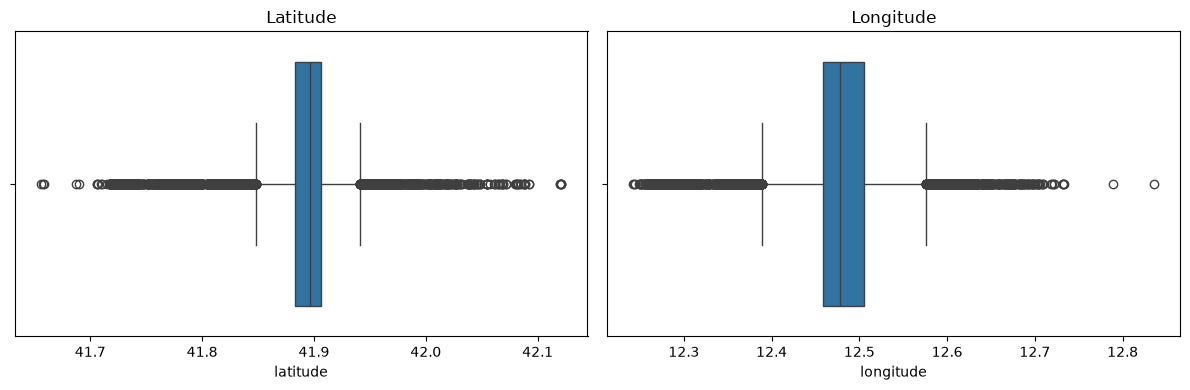

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=selected["latitude"], ax=axes[0])
axes[0].set_title("Latitude")

sns.boxplot(x=selected["longitude"], ax=axes[1])
axes[1].set_title("Longitude")

plt.tight_layout()
plt.show()

As we can see the number of observations decrease to 30987. This means that around 3000 were outliers.

In [220]:
def remove_outliers_iqr_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series >= lower_bound) & (series <= upper_bound)

valid_mask = remove_outliers_iqr_mask(coords["latitude"]) & remove_outliers_iqr_mask(coords["longitude"])
coords = coords.loc[valid_mask].copy()

print(coords.shape)

(30158, 2)


## 11.3 Standardization of the observations

To account for variations in measurement units and scale, we standardize the data in order to preserve the relationships between features.


In [221]:
# Standardize coordinates before K-Means
scaler = StandardScaler()
coords[["latitude_scaled", "longitude_scaled"]] = scaler.fit_transform(coords[["latitude", "longitude"]])


coords.head()

,latitude,longitude,latitude_scaled,longitude_scaled
0,41.871360,12.482150,-1.517168,-0.057379
1,41.895447,12.491181,-0.000597,0.226252
2,41.925820,12.469280,1.911786,-0.461562
3,41.908230,12.452930,0.804270,-0.975034
4,41.908283,12.452617,0.807622,-0.984874


After this steps we are in position to cluster the data. 

First, we need to know the number of clusters we are going to create, so we have to find the optimal number.To do this we are going to use the ELBOW METHOD. The Elbow plot allows us to plot the inertia, which is a measure of how well the data was clustered by the k-means algorithm, against the number of clusters. From this plot, we are looking for a point where the inertia begins to slow.

## 11.4 Spatial Clustering with K-Means

## Elbow Method

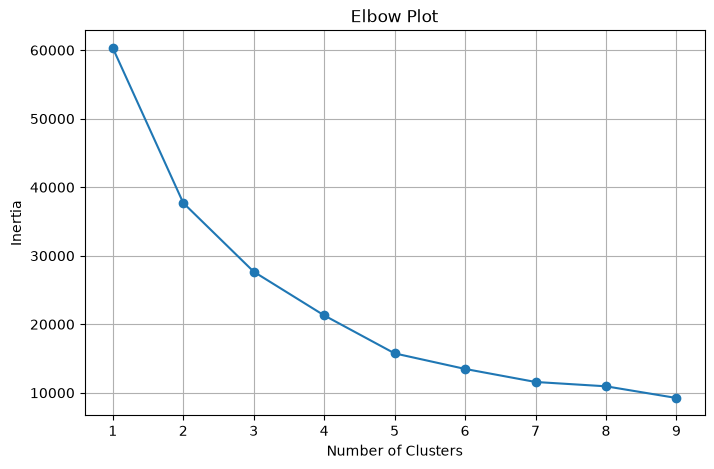

In [222]:
# Create a function to work out the optimum number of clusters
def k_means_plot_elbow(data:pd.DataFrame, max_k:int):
	cluster_sizes = [ ]
	inertias = [ ]

	for k in range(1, max_k):
		kmeans = KMeans(n_clusters=k, random_state=42)
		kmeans.fit(data)

		cluster_sizes.append(k)
		inertias.append(kmeans.inertia_)

	# Generate the elbow plot
	plt.figure(figsize=(8, 5))
	plt.plot(cluster_sizes, inertias, 'o-')
	plt.xlabel('Number of Clusters')
	plt.ylabel('Inertia')
	plt.title('Elbow Plot')
	plt.grid(True)
	plt.show()

k_means_plot_elbow(coords[['latitude_scaled', 'longitude_scaled']], 10)

## Elbow Plot Analysis

The elbow plot shows the inertia (sum of squared distances from each point to its 
cluster centroid) as a function of the number of clusters k.

Ideally, we look for the point where the curve bends sharply (the "elbow") 
indicating that adding more clusters no longer significantly reduces inertia.

In this case, the curve decreases steeply from k=1 to k=4, and then begins to 
flatten out. However, there is no single sharp elbow ,the reduction in inertia 
continues gradually beyond k=4, making it difficult to determine an optimal k 
from this plot alone.

Based on the elbow plot, k=5 appears to be a reasonable choice, as the marginal 
gain in inertia reduction becomes less pronounced after this point. To validate 
this decision, we complement the elbow method with a Silhouette analysis, which 
provides a more rigorous measure of cluster quality.

## Silhouette

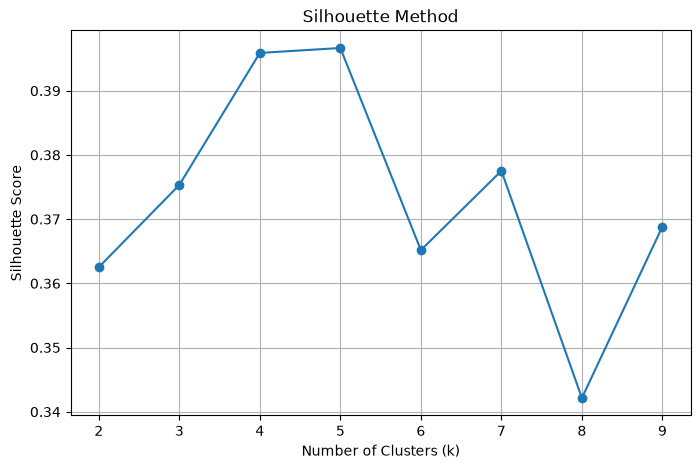

The optimal number of clusters is: 5


In [223]:
from sklearn.metrics import silhouette_score

def k_means_plot_silhouette(data:pd.DataFrame, max_k:int):
    silhouette_scores = []
    k_values = range(2, max_k)  # k must be at least 2

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)  # Cluster labels
        score = silhouette_score(data, labels)  # Compute silhouette score
        silhouette_scores.append(score)

    # Plot the silhouette scores
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, silhouette_scores, marker='o')
    plt.title("Silhouette Method")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    # Find the best number of clusters
    best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
    print(f"The optimal number of clusters is: {best_k}")
    return best_k

best_k = k_means_plot_silhouette(coords[['latitude_scaled', 'longitude_scaled']], 10)

After running the Silhoutte method we confirm that te optimal number of clusters is 5.

For n_clusters = 2 The average silhouette_score is : 0.3563228069303234
For n_clusters = 3 The average silhouette_score is : 0.37509499181723077
For n_clusters = 4 The average silhouette_score is : 0.3957433236894801
For n_clusters = 5 The average silhouette_score is : 0.39624033106504064


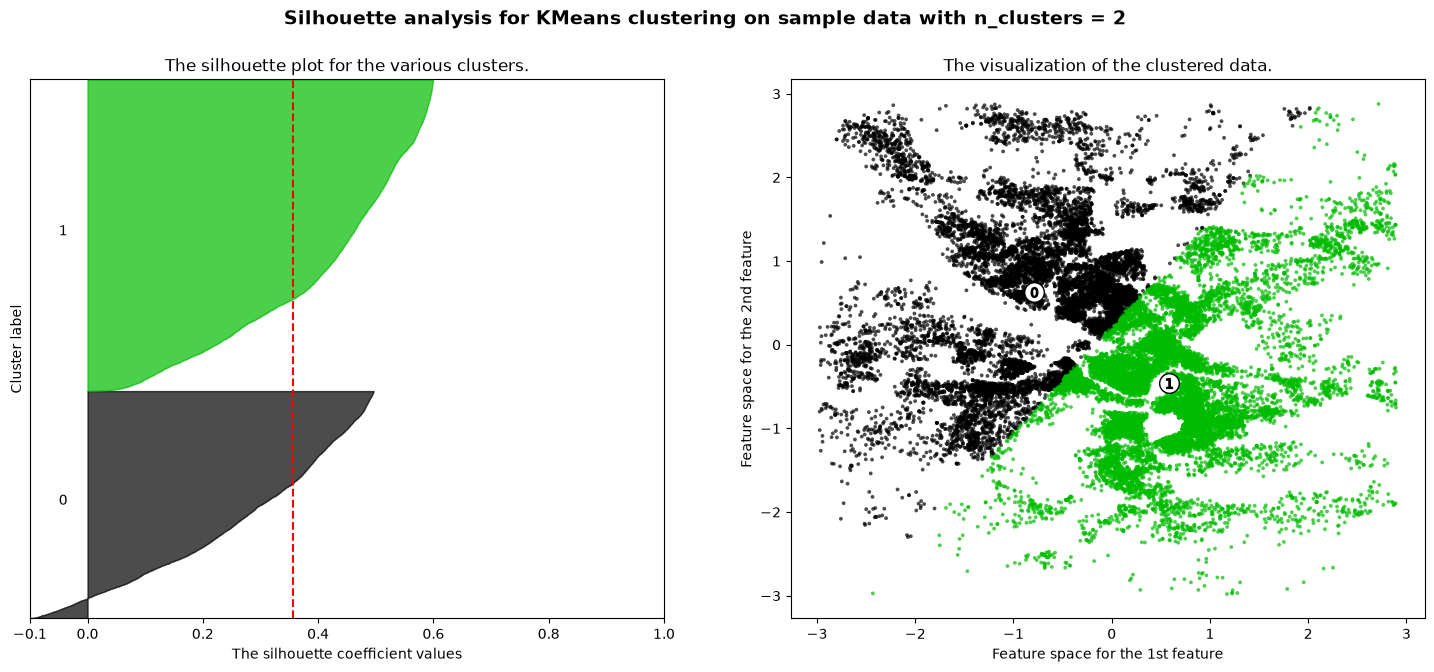

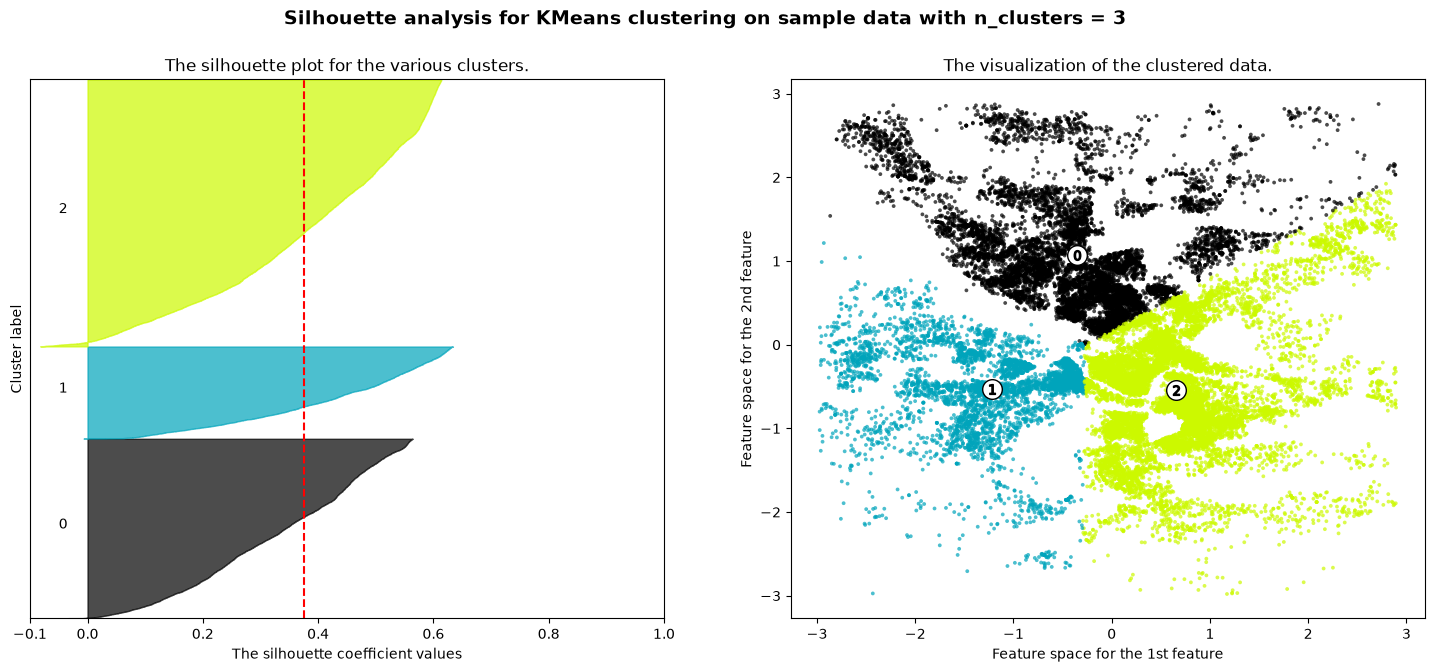

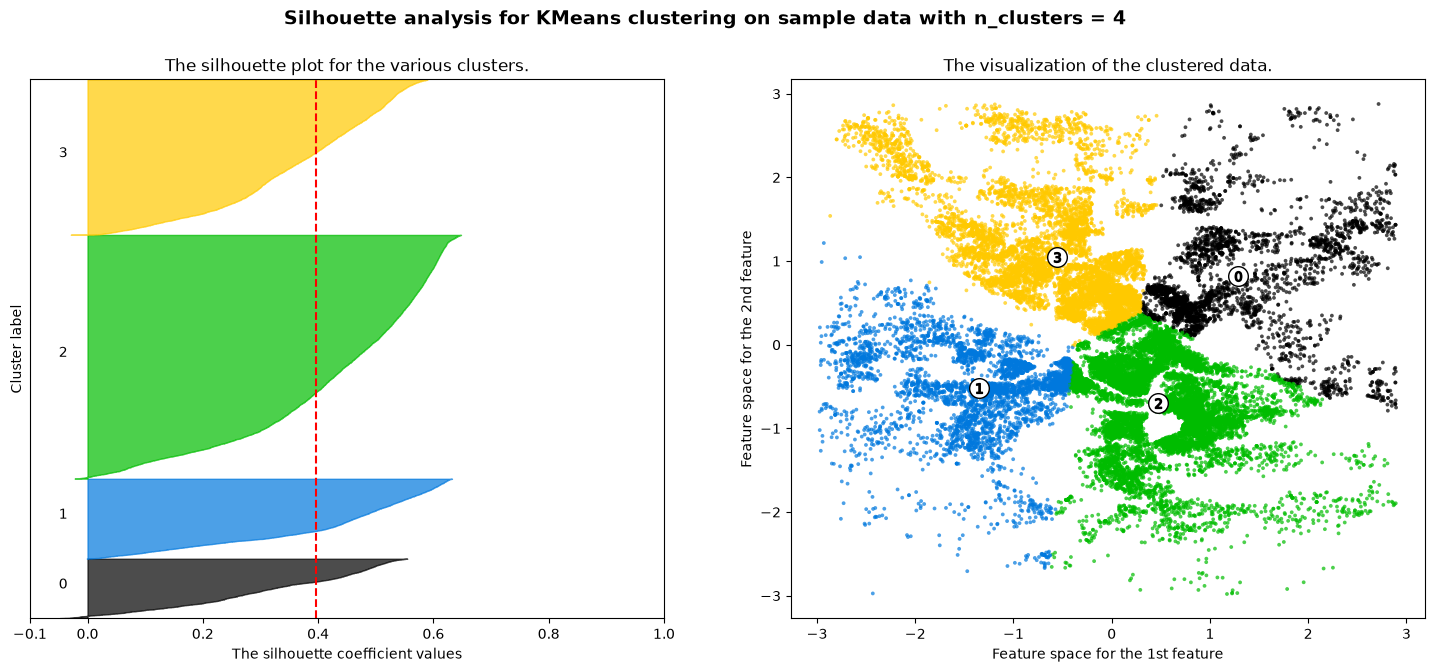

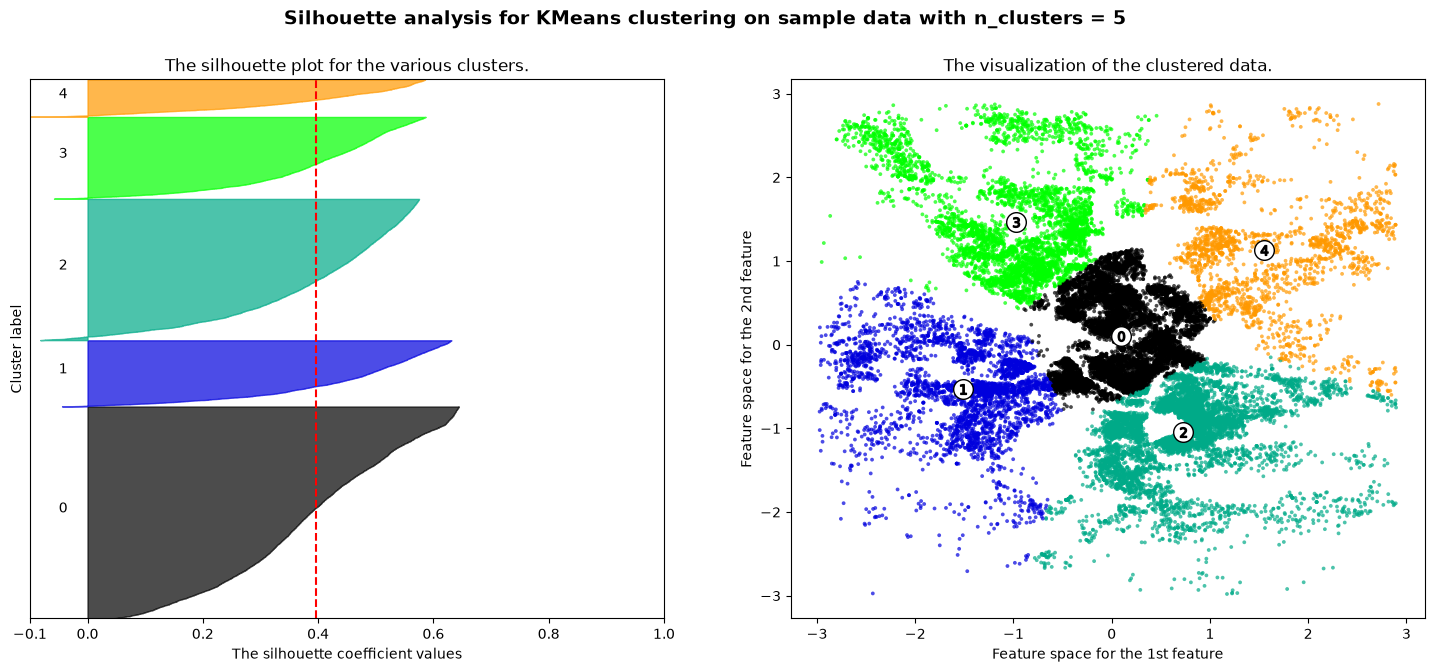

In [224]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
# adapted from https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
def silhouette_sklearn(X:np.ndarray, clusters:range):
    for n_clusters in clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, random_state=10)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print(
            "For n_clusters =",
            n_clusters,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(
            X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="white",
            alpha=1,
            s=200,
            edgecolor="k",
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

    plt.show()

silhouette_sklearn(coords[['latitude_scaled', 'longitude_scaled']].values, range(2, 6))

K-Means is fitted using the number of clusters selected through the elbow and silhouette analyses.

In [237]:
# K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
coords["location_cluster"] = kmeans.fit_predict(coords[["latitude_scaled", "longitude_scaled"]])

# merge back into selected using index
selected = selected.merge(
    coords[["location_cluster"]],
    left_index=True,
    right_index=True,
    how="left"
)

print("Listings with cluster assigned:", coords.shape[0])
print("Listings without cluster (outliers):", selected["location_cluster"].isnull().sum())
selected.head(10)

Listings with cluster assigned: 30158
Listings without cluster (outliers): 3406


,id,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,neighbourhood_cleansed_X Ostia/Acilia,neighbourhood_cleansed_XI Arvalia/Portuense,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum,location_cluster_x,location_cluster_y,location_cluster
0,2737,57.0,41.871360,12.482150,Private Room,Private room,1,1.0,1.0,1.5,...,False,False,False,False,False,False,2.252726,3.0,3.0,3.0
1,11834,110.0,41.895447,12.491181,Apartment,Entire home/apt,2,1.0,1.0,1.0,...,False,False,False,False,False,False,0.588865,4.0,4.0,4.0
2,12398,124.0,41.925820,12.469280,Apartment,Entire home/apt,6,2.0,3.0,1.0,...,False,False,False,False,False,False,4.389669,1.0,1.0,1.0
3,19965,162.0,41.908230,12.452930,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,False,False,3.824847,1.0,1.0,1.0
4,19967,150.0,41.908283,12.452617,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,False,False,3.850102,1.0,1.0,1.0
5,20534,195.0,41.889920,12.468230,Entire Home,Entire home/apt,4,1.0,3.0,1.0,...,False,False,False,False,False,False,1.989591,4.0,4.0,4.0
6,20587,245.0,41.889920,12.468230,Entire Home,Entire home/apt,4,2.0,4.0,1.0,...,False,False,False,False,False,False,1.989591,4.0,4.0,4.0
7,20699,95.0,41.892940,12.505810,Private Room,Private room,2,1.0,1.0,1.0,...,False,False,False,False,False,False,1.169793,4.0,4.0,4.0
9,21811,136.0,41.890840,12.468040,Entire Home,Entire home/apt,4,0.0,2.0,1.0,...,False,False,False,False,False,False,2.006361,4.0,4.0,4.0
10,22930,157.0,41.889920,12.468230,Apartment,Entire home/apt,2,1.0,1.0,1.5,...,False,False,False,False,False,False,1.989591,4.0,4.0,4.0


## 11.5 Density-Based Clustering with DBSCAN

Now we are going to use DBSCAN to cluster the data. For this model we need to define the parameter of Epsilon (ε) which  is the maximum radius DBSCAN uses to search for neighboring data points. If point B is within distance ε of point A, they are considered neighbors. Setting ε too small leaves valid clusters fragmented as noise; setting it too large merges distinct clusters together.

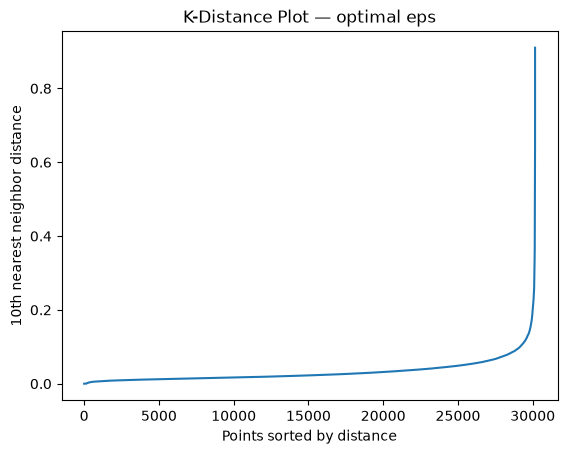

In [226]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors.fit(coords[["latitude_scaled", "longitude_scaled"]])
distances, _ = neighbors.kneighbors(coords[["latitude_scaled", "longitude_scaled"]])

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("10th nearest neighbor distance")
plt.title("K-Distance Plot — optimal eps")
plt.show()

Approximately observing the plot, the Epsilon (ε) value is 0.1.

In [227]:
# DBSCAN with density-based clustering
sc = DBSCAN(eps=0.1, min_samples=10)
coords["dbscan_cluster"] = sc.fit_predict(coords[["latitude_scaled", "longitude_scaled"]])

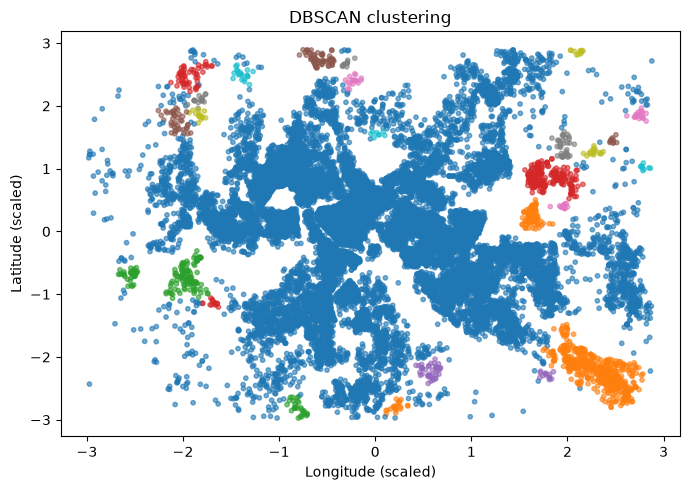

In [228]:
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(coords["longitude_scaled"], coords["latitude_scaled"], c=coords["dbscan_cluster"], cmap="tab10", s=10, alpha=0.6)
ax.set_title("DBSCAN clustering")
ax.set_xlabel("Longitude (scaled)")
ax.set_ylabel("Latitude (scaled)")

plt.tight_layout()
plt.show()


The DBSCAN clustering plot reveals an important characteristic of the Rome Airbnb 
dataset: the vast majority of listings form a single large dense cluster (shown in 
blue), which corresponds to the central and most active areas of Rome where Airbnb 
listings are heavily concentrated. 

The smaller clusters scattered around the edges represent distinct neighborhoods 
or suburban areas that are geographically separated from the main urban core, 
with sufficient local density to form their own clusters.

For this reason, **K-Means with k=5 is preferred for the modeling phase**, as it 
forces a more balanced geographic segmentation of the city and assigns every 
listing to a cluster without producing noise points. DBSCAN remains valuable as 
an exploratory tool to confirm the geographic density structure of the dataset.

## 12. Export Processed Dataset

The cleaned and feature-engineered dataset is exported and will serve as input for subsequent modeling notebooks.

In [235]:
print(selected.shape)


(33564, 60)


## Final Feature Set

The final dataset contains:

- Original listing characteristics
- Host-related features
- Review-based features
- Availability indicators
- Geographic variables
- Spatial clustering features

The resulting dataset will be used as input for predictive modeling.

In [230]:
selected.to_csv(
    "../data/listings_features.csv",
    index=False
)

print("listings_features.csv saved")

listings_features.csv saved
